In [1]:
import dr3_to_mcsampled as mc
import numpy as np

mc.SPECTRAL_POINTS = np.arange(336, 1021, 2)

# rec = mc.get_sample_rec(4295806720, own_covariances=False)
# rec = mc.get_sample_rec(38655544960, own_covariances=False)
rec = mc.get_sample_rec(382128703524478208, own_covariances=False)

In [2]:
from gaiaxpy import calibrate
import pandas

calib, _ = calibrate(
    pandas.DataFrame.from_records([rec]),
    # sampling=mc.SPECTRAL_POINTS,
    truncation=True,
    save_file=False,
)

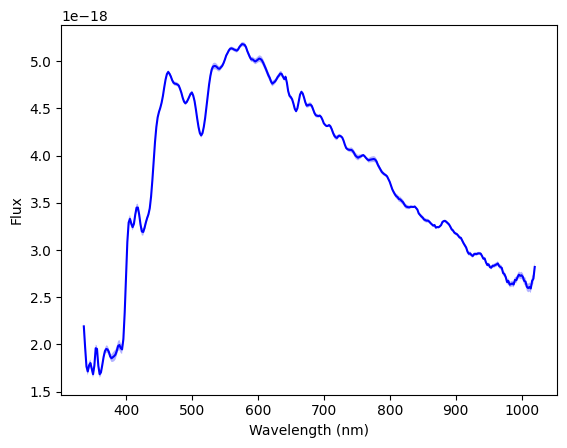

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams["text.usetex"] = False

flux = calib["flux"][0].astype(np.float32)
flux_error = calib["flux_error"][0].astype(np.float32)

fig, ax = plt.subplots()
ax.plot(mc.SPECTRAL_POINTS, flux, label="Original", alpha=1.0, color="blue")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Flux")

ax.fill_between(
    mc.SPECTRAL_POINTS,
    flux - flux_error,
    flux + flux_error,
    alpha=0.3,
    facecolor="blue",
)

plt.show()

In [4]:
samples = mc.get_mc_realisations(rec, 10)

spectra = []
for sample in mc.get_sampled(samples):
    spectra.append(sample)

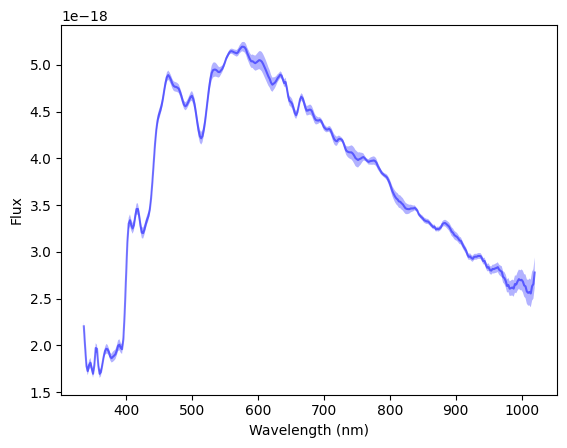

In [5]:
flux = spectra[0][1].astype(np.float32)
flux_error = spectra[0][2].astype(np.float32)

fig, ax = plt.subplots()
ax.plot(mc.SPECTRAL_POINTS, flux, label="Original", alpha=0.5, color="blue")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Flux")

ax.fill_between(
    mc.SPECTRAL_POINTS,
    flux - flux_error,
    flux + flux_error,
    alpha=0.3,
    facecolor="blue",
)

plt.show()